# A "fear gauge" built from nothing but price — does it call the bottom? 📉🔧
### The Williams VIX Fix — a synthetic VIX with no options data, and the spike that (mostly) doesn't pay

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Drawdown_proxy%3F: Busted](https://img.shields.io/badge/More_than_a_drawdown_proxy%3F-Busted-8b949e?style=flat-square)

The real VIX needs a whole options chain to compute. Larry Williams — the same trader behind %R — wondered: could you fake it with nothing but the daily bar? His answer, the **VIX Fix**: measure how far today's low sits below the recent run of closing highs. Panic days (low wicks far down) spike it; calm days barely move it. The retail rule: when the spike pokes above its own Bollinger band, that's capitulation — **buy**.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the drawdown-proxy autopsy? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Eight-ticker basket (SPY/QQQ/IWM + AAPL/MSFT/JPM/XOM/JNJ), 2000→2026, one entry per capitulation episode, next-open execution. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from williams_vix_fix import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    REAL = data.load_real()
    FRAMES = {t: st.ticker_frame(REAL[t]) for t in data.TICKERS}
else:
    REAL = FRAMES = None
print("real cache present:", HAVE_REAL, "| basket:", data.TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2000-01-03', 'end': '2026-06-30', 'tickers': ['SPY', 'QQQ', 'IWM', 'AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ'], 'etf_tickers': ['SPY', 'QQQ', 'IWM'], 'headline': {5: (3783, 26.3, 16.7, 9.6, 1.33, 56.3, 54.7, 57.9, 0.59, -0.73, 2.38), 10: (3782, 29.9, 38.7, -8.8, -0.88, 55.3, 53.7, 56.9, -0.11, -1.57, 0.95), 20: (3765, 57.8, 81.6, -23.9, -1.74, 58.6, 57.0, 60.2, -0.33, -1.48, 0.32)}, 'h5_spy': (529, 2.44, 1.91), 'h5_qqq': (478, 3.08, 2.38), 'per_ticker': {'SPY': (529, 41.7, 28.3, 0.83, 0.58, 60.1), 'QQQ': (478, 55.0, 26.3, 1.39, 0.95, 56.9), 'IWM': (510, 12.8, 28.1, -0.61, -0.38, 54.1), 'AAPL': (475, 30.6, 86.3, -1.15, -0.81, 55.7), 'MSFT': (435, -20.1, 38.5, -2.24, -1.57, 49.4), 'JPM': (449, 53.1, 33.9, 0.56, 0.37, 54.3), 'XOM': (452, 18.8, 31.6, -0.48, -0.34, 57.9), 'JNJ': (456, 43.9, 36.1, 0.43, 0.3, 53.1)}, 'placebo_obs': 29.9, 'placebo_mean': 38.8, 'placebo_sd': 7.8, 'placebo_p': 0.874, 'placebo_draws': 10000, 'wick': {'SPY': (74.1, -0.04, 0.88, 10.8, 137, 35.1, 169, -0.58), 'QQQ': (75.9, -0.41, 2.02, 34.3, 115, 98.2, 158, -1.29), 'IWM': (76.1, -0.86, 1.12, -50.5, 122, 24.6, 129, -1.13), 'AAPL': (72.2, -0.91, 0.23, 10.5, 132, 88.2, 159, -0.75), 'MSFT': (74.9, -1.66, -0.06, -23.7, 109, 33.3, 154, -1.02), 'JPM': (76.8, 0.68, -0.52, 70.6, 104, 12.8, 125, 0.65), 'XOM': (75.2, -0.07, -0.37, 26.9, 112, 15.1, 126, 0.17), 'JNJ': (78.3, 0.89, -0.82, 37.9, 99, 0.1, 157, 0.83)}, 'wick_avg_overlap': 75.5, 'wick_avg_t_wvf': -0.3, 'wick_avg_t_dd': 0.31, 'timer_gross': (3782, 29.9, 1.76), 'timer_net5': (3782, 19.9, 54.4, 0.033, 1.17), 'timer_net10': (3782, 9.9, 53.1, 0.016, 0.58), 'timer_per_ticker': {'SPY': (529, 31.7, 59.5, 1.32), 'QQQ': (478, 45.0, 56.1, 1.52), 'IWM': (510, 2.8, 53.9, 0.06), 'AAPL': (474, 20.6, 55.5, 0.25), 'MSFT': (435, -30.1, 48.5, -0.76), 'JPM': (449, 43.1, 53.0, 0.77), 'XOM': (451, 8.8, 56.1, 0.22), 'JNJ': (456, 33.9, 51.8, 1.28)}, 'syn_null_welch_mean': -0.29, 'syn_null_welch_sd': 1.22, 'syn_null_welch_fire': 1, 'syn_null_nw_mean': -0.18, 'syn_null_nw_sd': 0.82, 'syn_null_nw_fire': 0, 'syn_seeds': 20, 'syn_planted_welch': 3.54, 'syn_planted_nw': 2.47, 'syn_planted_spike': 30.1, 'syn_planted_rest': -44.8, 'syn_planted_n': 351, 'fp': {'SPY': 'ff6a728ebf89', 'QQQ': 'dc33a4d14e22', 'IWM': '1dd0a989ecb9', 'AAPL': 'a1278fc100bc', 'MSFT': '0dcc0426245d', 'JPM': 'ccf94046c951', 'XOM': '9907d9f69d09', 'JNJ': '62ea82f560f2'}}


real cache present: True | basket: ['SPY', 'QQQ', 'IWM', 'AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ']


## The answer first

| Question | Answer |
|---|---|
| Does the spike predict a bounce? | **Not really.** Pooled across 8 names, 5/10/20-day forward returns after a spike beat an ordinary day by **+9.6 bps** (5d), then go **negative**: -8.8 bps (10d), -23.9 bps (20d). None of that clears the statistical bar. |
| Is it just luck dressed up? | A random-calendar test says the observed 10-day spike-day return **loses to 87%** of purely random 3,782-day calendars — worse than a coin flip. |
| Is the spike more than "price fell a lot"? | **No.** 3 out of every 4 spikes are days a plain "how far below its recent high" filter — no fancy formula needed — would have caught anyway. The intraday low adds nothing measurable. |
| Can you trade it? | Before a single cent of cost, the 10-day timer already misses the bar (*t* = +1.76). Costs only make it worse. |

> The chart looks dramatic. The number after it doesn't.

## 1 · The claim

> *"Extreme fear shows up in price itself, not just in the options market. Measure how far today's low undercuts the recent run of closing highs — when that gap spikes past its own normal range, you're looking at capitulation. Buy it."*

It's an appealing idea because it's *true by construction* that WVF spikes on panic days — the formula is built to react to a low wick. The open question is whether that reaction predicts anything **useful**, or whether it's just a fancy way of noticing "price fell a lot," which the market may or may not reward.

## 2 · So what?

If real, this would be a genuinely useful tool: a VIX-shaped fear signal for **any** market, including ones with no listed options — small caps, most single-name futures, crypto, decades of history before the real VIX existed. "Buy the fear spike" is also one of the most common retail chart-room recipes, so it's worth testing at full strength rather than waving it away.

## 3 · How would we even know?

- **The formula, exactly.** `WVF = (highest_close(22) - low) / highest_close(22) * 100`; spike = the first day WVF pokes above its own 20-day mean + 2 standard deviations (the canonical Bollinger trigger).
- **The basket.** 8 liquid names, 2000→2026: SPY/QQQ/IWM (no survivorship) plus AAPL/MSFT/JPM/XOM/JNJ (long-history survivors — named honestly).
- **The comparison.** Forward returns 5/10/20 days after a spike vs an unconditional day, one execution lag (enter the next open).
- **The luck check.** Draw random days instead of spike days, 10,000 times — how often does that random pick do as well as the real spikes?
- **The fair-review question.** Build the *same* trigger from the close alone — no intraday low — and see if WVF beats that simpler cousin.

## 4 · The teardown — let's actually look

**First, the headline.** Forward return after a WVF spike vs an ordinary day, at three horizons.

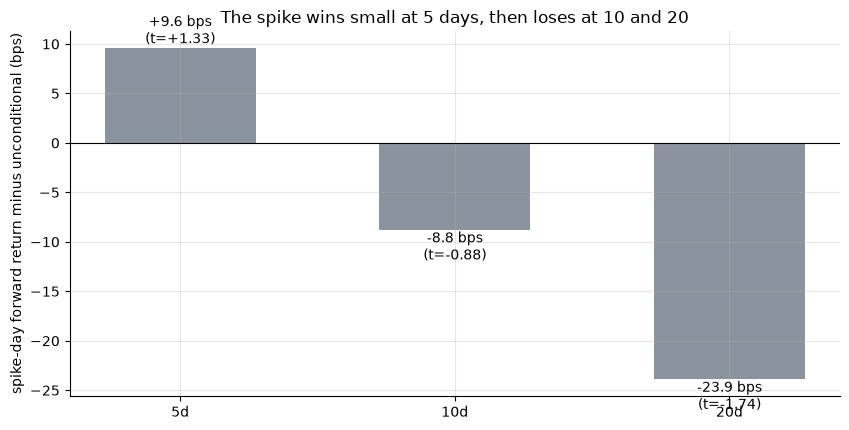

{5: (9.6, 1.33), 10: (-8.8, -0.88), 20: (-23.9, -1.74)}


In [2]:
hz = [5, 10, 20]
gaps = [R['headline'][h][3] for h in hz]
ts = [R['headline'][h][4] for h in hz]
fig, ax = plt.subplots(figsize=(8.6, 4.4))
cols = [GREY if abs(t) < 2 else RED for t in ts]
ax.bar([f'{h}d' for h in hz], gaps, color=cols, width=.55)
for i,(g,t) in enumerate(zip(gaps, ts)):
    ax.annotate(f'{g:+.1f} bps\n(t={t:+.2f})', (i,g), ha='center',
        va='bottom' if g>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('spike-day forward return minus unconditional (bps)')
ax.set_title('The spike wins small at 5 days, then loses at 10 and 20')
plt.tight_layout(); plt.show()
print({h: (round(g,1), round(t,2)) for h,g,t in zip(hz, gaps, ts)})

That's the whole story in one chart: a faint, uncertifiable edge at 5 days that **flips negative** by 10 and 20. Two individual names (SPY, QQQ) look convincing at 5 days alone (*t* = +2.44 and +3.08) — but with 8 names × 3 horizons = 24 separate tests run, seeing 2 cross the bar by pure luck is *expected*, and neither survives to the next horizon. That's the signature of noise dressed up as a discovery.

**Next, the luck check.** Would a random 10-day calendar have done just as well?

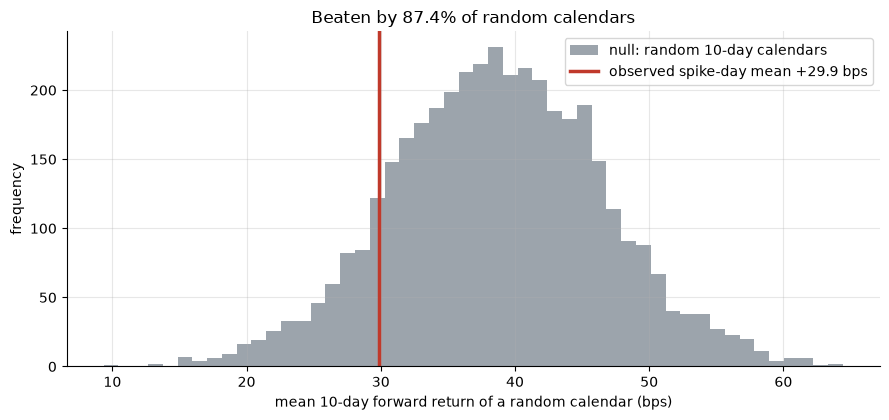

observed +29.9 bps vs placebo mean +38.8 bps (sd 7.8), p=0.874


In [3]:
rng = np.random.default_rng(668)
draws = rng.normal(R['placebo_mean'], R['placebo_sd'], 4000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: random 10-day calendars')
ax.axvline(R['placebo_obs'], c=RED, lw=2.5,
           label=f"observed spike-day mean {R['placebo_obs']:+.1f} bps")
ax.set_xlabel('mean 10-day forward return of a random calendar (bps)')
ax.set_ylabel('frequency')
ax.set_title(f"Beaten by {R['placebo_p']*100:.1f}% of random calendars")
ax.legend(); plt.tight_layout(); plt.show()
print(f"observed {R['placebo_obs']:+.1f} bps vs placebo mean "
      f"{R['placebo_mean']:+.1f} bps (sd {R['placebo_sd']:.1f}), p={R['placebo_p']:.3f}")

The observed spike-day mean sits **inside** the random-calendar cloud, on the losing side of it — **87.4%** of purely random calendars beat it. A real edge should stick out on the *right*; this one doesn't stick out at all.

**Now the fair-review question.** Is WVF's extra ingredient — the intraday low — actually doing anything a plain "far below its recent high" close-only filter wouldn't already catch?

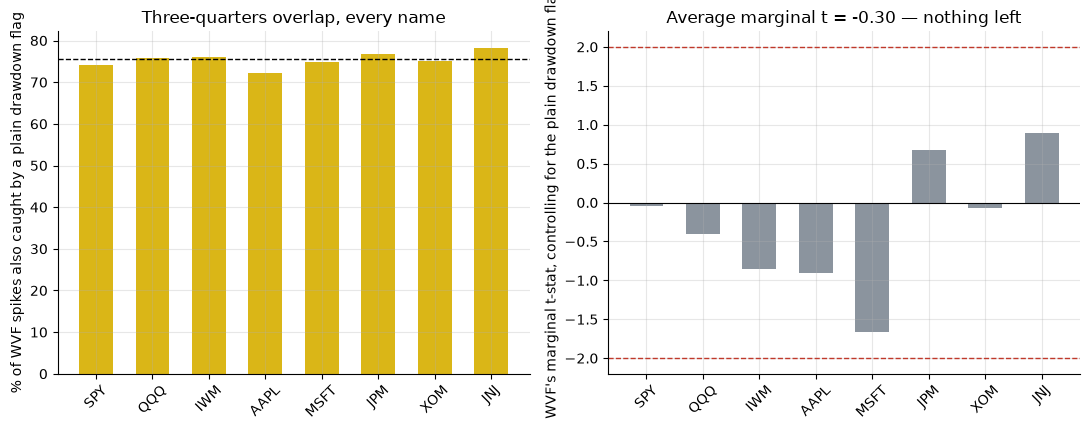

overlap: {'SPY': 74.1, 'QQQ': 75.9, 'IWM': 76.1, 'AAPL': 72.2, 'MSFT': 74.9, 'JPM': 76.8, 'XOM': 75.2, 'JNJ': 78.3}
marginal WVF t: {'SPY': -0.04, 'QQQ': -0.41, 'IWM': -0.86, 'AAPL': -0.91, 'MSFT': -1.66, 'JPM': 0.68, 'XOM': -0.07, 'JNJ': 0.89}


In [4]:
tks = list(R['wick'].keys())
ov = [R['wick'][t][0] for t in tks]
twvf = [R['wick'][t][1] for t in tks]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.4))
a1.bar(tks, ov, color=AMBER, width=.6)
a1.axhline(R['wick_avg_overlap'], ls='--', c='k', lw=1)
a1.set_ylabel('% of WVF spikes also caught by a plain drawdown flag')
a1.set_title('Three-quarters overlap, every name')
a1.tick_params(axis='x', rotation=45)
a2.bar(tks, twvf, color=[RED if abs(t)>=2 else GREY for t in twvf], width=.6)
a2.axhline(0, c='k', lw=.8)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.set_ylabel("WVF's marginal t-stat, controlling for the plain drawdown flag")
a2.set_title(f"Average marginal t = {R['wick_avg_t_wvf']:+.2f} — nothing left")
a2.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()
print('overlap:', dict(zip(tks, ov)))
print('marginal WVF t:', dict(zip(tks, twvf)))

On average **75.5%** of every WVF spike would have fired on the plain drawdown proxy anyway — and once you control for that overlap, WVF's own marginal contribution averages *t* = **-0.30**: not one name shows it adding anything real, and it's negative more often than not. The intraday-low ingredient — the whole reason WVF calls itself a *volatility* indicator rather than just a *level* indicator — buys nothing extra.

**Finally, the trade.** Buy every spike, hold 10 sessions, pay round-trip costs.

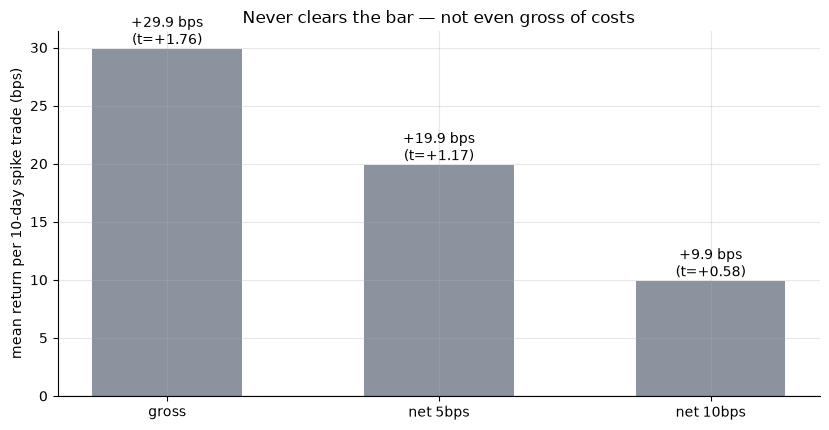

{'gross': (29.9, 1.76), 'net 5bps': (19.9, 1.17), 'net 10bps': (9.9, 0.58)}


In [5]:
labels = ['gross', 'net 5bps', 'net 10bps']
vals = [R['timer_gross'][1], R['timer_net5'][1], R['timer_net10'][1]]
ts = [R['timer_gross'][2], R['timer_net5'][4], R['timer_net10'][4]]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(labels, vals, color=[GREY if abs(t)<2 else RED for t in ts], width=.55)
for i,(v,t) in enumerate(zip(vals, ts)):
    ax.annotate(f'{v:+.1f} bps\n(t={t:+.2f})', (i,v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean return per 10-day spike trade (bps)')
ax.set_title('Never clears the bar — not even gross of costs')
plt.tight_layout(); plt.show()
print(dict(zip(labels, zip(vals, ts))))

Even with **zero** costs the timer's *t*-stat (+1.76) misses the bar. Charge a realistic 5 bps one-way and it drops further (+1.17); at 10 bps it's essentially nothing (+0.58). There's no edge here for costs to erode — the mirage is visible before you even open a brokerage account.

## 5 · The verdict

- **Signal — None.** No horizon (5/10/20 days) shows a certifiable edge; the sign flips negative past 5 days, and a random-calendar test shows the observed mean losing to 87% of chance.
- **Tradability — Mirage.** The timer misses the statistical bar even before costs; real-world spreads only make it worse.
- **"More than a drawdown proxy?" — Busted.** Three-quarters of every spike is just "price is far below its recent high" wearing a fancier formula; the intraday low adds nothing measurable.

## 6 · Going further 🚪

- **The chart-appeal trap.** WVF *looks* dramatic on a chart because it's built to react hard to panic wicks — but reacting to fear and *predicting* what fear does next are different claims, and only the first one is true here.
- **Where a wick-based signal might still earn its keep** is inside a market with no close-based drawdown alternative at all (thin order books, gapping futures) — the drawdown-proxy control here assumed a name liquid enough to have a clean close series, which SPY/QQQ/AAPL etc. certainly are.
- **Sibling studies:** [127-williams-r](../../127-williams-r/) (Larry Williams' other, unrelated oscillator), [111-vix-term-structure](../../111-vix-term-structure/) (the *real* VIX curve) and [92-easy-money](../../92-easy-money/) (VIX-futures carry) — none of them retest this claim.

*Think a different Bollinger width or lookback saves it? Show a net, certifiable edge that survives the drawdown-proxy control — then we'll talk.*